## Experiment: Classification Algorithms

### Simple Example: k-Nearest Neighbors (k-NN)

This example demonstrates the fundamental concept of the k-NN algorithm using a small, built-in dataset from scikit-learn. k-NN is a simple, instance-based learning algorithm that classifies new data points based on the majority class of their 'k' nearest neighbors in the feature space.

In [1]:
# Import necessary libraries
from sklearn.datasets import load_iris # To load the Iris dataset, a classic dataset for classification
from sklearn.model_selection import train_test_split # To split data into training and testing sets
from sklearn.neighbors import KNeighborsClassifier # The k-NN classification algorithm
from sklearn.metrics import accuracy_score # To evaluate the model's performance

# 1. Load the dataset
# The Iris dataset contains 150 samples of iris flowers, with 4 features each,
# and is classified into 3 species. It's ideal for a simple classification demo.
iris = load_iris()
X = iris.data # Features of the flowers (e.g., sepal length, petal width)
y = iris.target # Target labels (the species of the flower: 0, 1, or 2)

# 2. Split the data into training and testing sets
# We split the data so we can train the model on one part and test its performance
# on unseen data. test_size=0.3 means 30% of the data will be used for testing.
# random_state ensures reproducibility of the split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize and train the k-NN classifier
# KNeighborsClassifier(n_neighbors=3) creates a k-NN model that considers
# the 3 nearest neighbors to classify a new point.
knn = KNeighborsClassifier(n_neighbors=3)
# The .fit() method trains the model using the training data.
# The model 'learns' by simply memorizing the training data points.
knn.fit(X_train, y_train)

# 4. Make predictions on the test set
# .predict() uses the trained k-NN model to classify the unseen test data.
y_pred = knn.predict(X_test)

# 5. Evaluate the model's performance
# accuracy_score compares the predicted labels (y_pred) with the true labels (y_test)
# and calculates the proportion of correctly classified samples.
accuracy = accuracy_score(y_test, y_pred)
print(f"k-NN Model Accuracy: {accuracy:.2f}") # Print the accuracy, formatted to two decimal places

k-NN Model Accuracy: 1.00


### Complex Application: Decision Tree Classification with Detailed Evaluation

This example uses a Decision Tree classifier, which is another popular algorithm that works by creating a tree-like model of decisions. We'll use a slightly more complex dataset and explore various evaluation metrics to get a comprehensive understanding of the model's performance, which is crucial in real-world applications. We'll also visualize the decision tree.


--- Model Evaluation ---
Accuracy: 0.96
Precision: 0.96
Recall: 0.96
F1-Score: 0.96

Confusion Matrix:
[[18  1  0]
 [ 0 21  0]
 [ 1  0 13]]


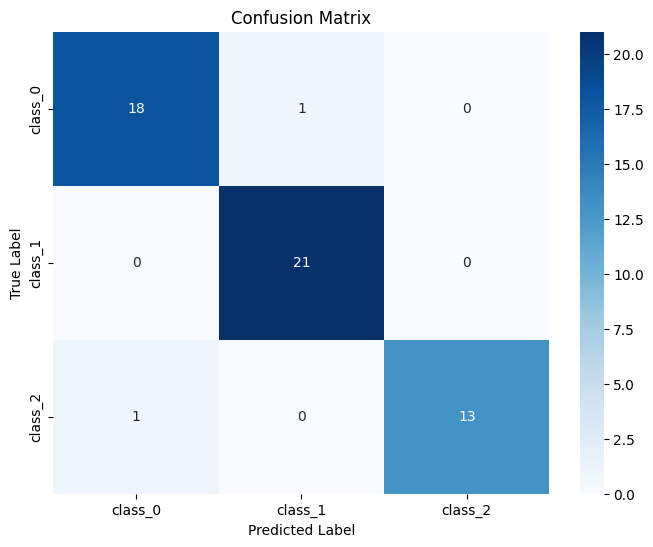

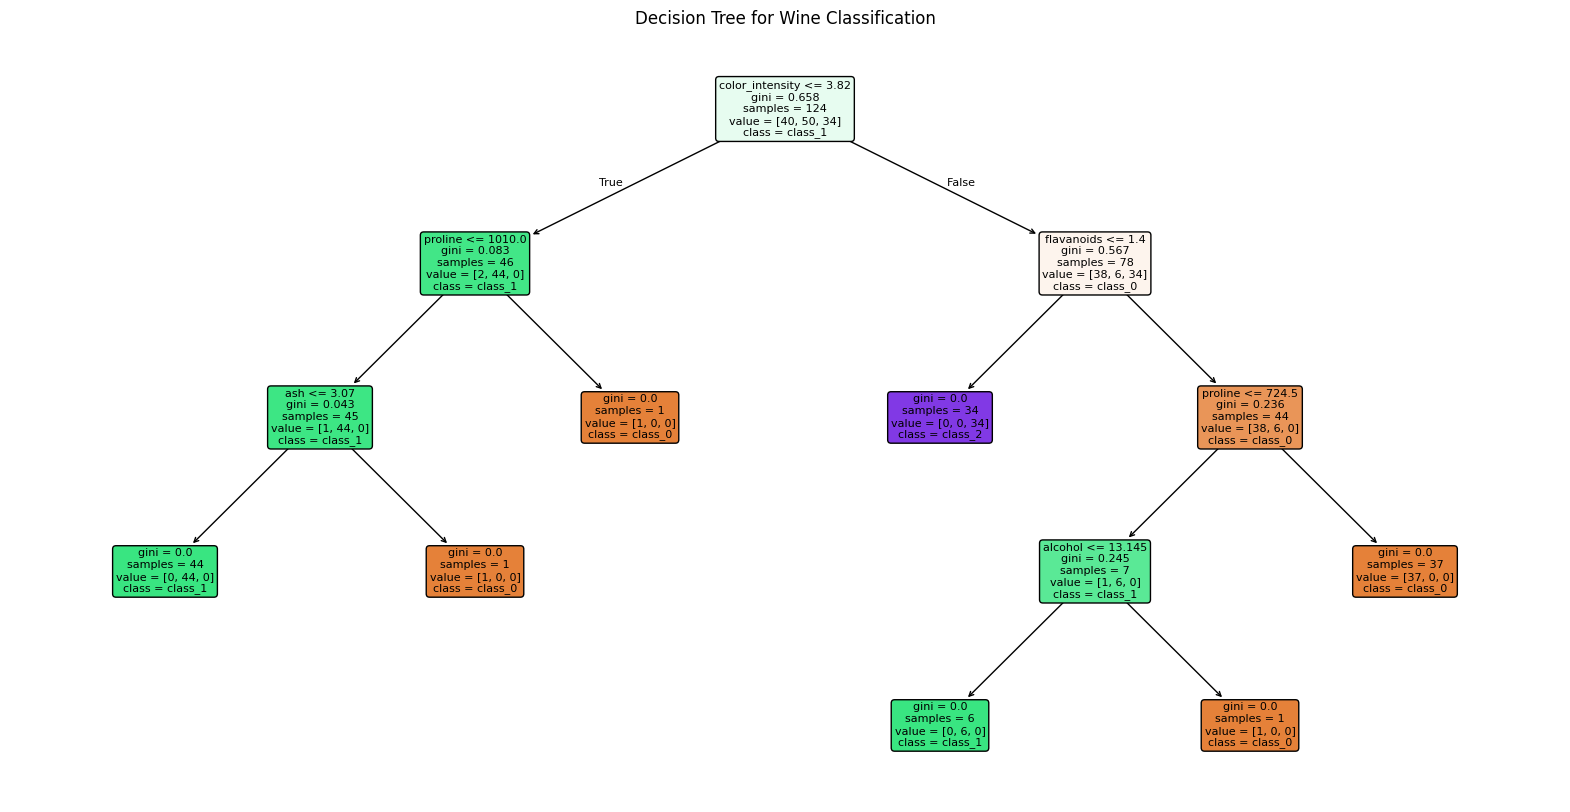

In [2]:
# Import necessary libraries
from sklearn.datasets import load_wine # To load the Wine dataset
from sklearn.tree import DecisionTreeClassifier, plot_tree # Decision Tree algorithm and plotting utility
from sklearn.model_selection import train_test_split # To split data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # Detailed evaluation metrics
import matplotlib.pyplot as plt # For plotting visualizations
import seaborn as sns # For enhanced statistical data visualization

# 1. Load the dataset
# The Wine dataset contains 178 samples of wine, with 13 features describing
# their chemical analysis, classified into 3 types of cultivators.
wine = load_wine()
X = wine.data # Features of the wines (e.g., alcohol, malic acid, ash)
y = wine.target # Target labels (the type of cultivator: 0, 1, or 2)
feature_names = wine.feature_names # Get the names of the features for better understanding
class_names = wine.target_names # Get the names of the target classes

# 2. Split the data into training and testing sets
# Again, 30% for testing and random_state for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize and train the Decision Tree classifier
# DecisionTreeClassifier() creates a decision tree model.
# random_state ensures reproducibility of the tree structure.
# max_depth=5 limits the tree depth to prevent overfitting and make it more interpretable.
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5)
# Train the model using the training data.
dt_classifier.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

# 5. Evaluate the model's performance using multiple metrics
print("\n--- Model Evaluation ---")

# Accuracy: Proportion of correctly classified instances.
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Precision: The ability of the classifier not to label as positive a sample that is negative.
# 'weighted' averaging considers imbalance in class sizes.
precision = precision_score(y_test, y_pred, average='weighted')
print(f"Precision: {precision:.2f}")

# Recall: The ability of the classifier to find all the positive samples.
# 'weighted' averaging considers imbalance in class sizes.
recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall: {recall:.2f}")

# F1-score: The harmonic mean of precision and recall. A good F1-score means low false positives and low false negatives.
# 'weighted' averaging considers imbalance in class sizes.
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score: {f1:.2f}")

# Confusion Matrix: A table used to describe the performance of a classification model
# on a set of test data for which the true values are known.
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the Confusion Matrix for better understanding
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 6. Visualize the Decision Tree
# This helps in understanding the decision-making process of the model.
plt.figure(figsize=(20, 10)) # Set figure size for better visibility
plot_tree(dt_classifier,
          feature_names=feature_names,
          class_names=class_names,
          filled=True, # Fill nodes with colors to indicate majority class
          rounded=True, # Round node corners
          fontsize=8) # Set font size for readability
plt.title('Decision Tree for Wine Classification')
plt.show()